# Ground Station Visibility
---
Last revised by Z. Ellis on 2026 APR 6

## Objectives
This tutorial will demonstrate 

See [Celestial Bodies](basics_CelestialBodies.ipynb)

## Imports and Set Up

Here we'll import the necessary libraries and load in the tutorials data folder. Then we define units and frames and load a metakernel for SPICE functionalities.

In [1]:
import scarabaeus as scb
from tutorial_data import tutorial_data

import os
import matplotlib.pyplot as plt

# load tutorial data
data = tutorial_data.load()

## units, frames, kernels
m, km, kg, sec, hr = scb.Units.get_units(['m', 'km', 'kg', 'sec', 'hr'])
J2000 = scb.Frame('J2000')

# load tutorial meta kernel
scb.SpiceManager.clear_kernels()    # ensure clean kernel pool
scb.SpiceManager.load_kernel_from_mkfile(data.mk)

SCB tutorial data up to date.


## Configure Bodies and Propagate Trajectory
Now we'll have to create an orbiter spacecraft as well as the Earth for it to orbit around. blah blah

First we create the Earth and attach DSN stations to it:

In [2]:
## configure primary body
# create an empty Earth
earth = scb.CelestialBody.from_constants('EARTH')

# define a few ground stations and attach them to Earth
DSS_14 = scb.GroundStation('DSS-14', 399014)
DSS_15 = scb.GroundStation('DSS-15', 399015)
DSS_24 = scb.GroundStation('DSS-24', 399024)
DSS_34 = scb.GroundStation('DSS-34', 399034)
DSS_54 = scb.GroundStation('DSS-54', 399054)

all_gs = [DSS_14, DSS_15, DSS_24, DSS_34, DSS_54]
earth.add_ground_station(all_gs)

now spacecraft

In [3]:
## configure the orbiter spacecraft
# create Spacecraft object
orbiter = scb.Spacecraft(name     = 'ORCCA_ORBITER',
                         spice_id = -1000,
                         tot_mass = scb.ArrayWUnits(2e3, kg),
                         area     = scb.ArrayWUnits(1, m**2))

# define propagation interval
t0 = scb.EpochArray(scb.SpiceManager.cal2et('2026 JAN 01 00:00:00.000'), 'TDB')
tf = scb.EpochArray(scb.SpiceManager.cal2et('2026 JAN 07 00:00:00.000'), 'TDB')
dt = scb.ArrayWUnits(1, hr)

epochs = scb.EpochArray.interval(t0, tf, dt)

# define initial state
pos0 = scb.ArrayWFrame(scb.ArrayWUnits([10e6, 0, 0], km    ), J2000)
vel0 = scb.ArrayWFrame(scb.ArrayWUnits([0   , 7, 0], km/sec), J2000)
x0   = scb.StateArray(epoch  = t0,
                      origin = earth,
                      state  = scb.StateDefinition()
                                  .position(orbiter, pos0)
                                  .velocity(orbiter, vel0))

## propagate the orbiter
# define keplerian dynamics, propagator, and propagate
kep_dyn = scb.ForceModelTranslation(orbiter)
prop    = scb.Propagator(primary_body = orbiter,
                         state_vector = x0,
                         tspan        = epochs,
                         force_models = kep_dyn)
prop.propagate()

## write trajectory file
# create directory in tutorial results folder if it doesn't exist yet
orbit_traj_path = os.path.join(tutorial_data.RESULTS_PATH, 'GS_vis_tut/')
if not os.path.exists(orbit_traj_path): os.mkdir(orbit_traj_path)

# write trajectory
orbit_traj = scb.Trajectory(os.path.join(orbit_traj_path, 'ORCCA_ORBITER_TRAJ'), state_array = prop.propagated_state_array)

/Users/zael5647/scarabaeus/src/scarabaeus/utils/SCBPolynomial.py:80: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(t_array, y_array, deg)



                            Starting propagation...                             


Integrating:   0%|                                                      | 0.00/518400.00 s [00:00<?]

Integrating:   0%|                                                      | 0.00/518400.00 s [00:00<?]

Integrating:   0%|                                               | 0.01/518400.00 s [00:00<35:54:58]

...

Integrating: 100%|█████████████████████████████████████████████| 518400.00/518400.00 s [00:00<00:00]

Integrating: 100%|█████████████████████████████████████████████| 518400.00/518400.00 s [00:00<00:00]

Integrating: 100%|█████████████████████████████████████████████| 518400.00/518400.00 s [00:00<00:00]

Integrating: 100%|█████████████████████████████████████████████| 518400.00/518400.00 s [00:00<00:00]


 =================== DOP853 integration complete. ==================
Propagation complete.


## Examine Visibility
blah blah

In [4]:
# compute visibility windows for each ground station
vis_windows, vis_window_nums = {}, {}
for gs in earth.gs_list:
    num_windows, windows = scb.SpiceManager.get_observer_target_visibility_windows(
                                            obsvr_bdy   = gs,
                                            trgt_bdy    = orbiter,
                                            epoch_start = epochs[0],
                                            epoch_end   = epochs[-1],
                                            step_size   = 60)
    # save amount of windows and the windows themselves
    vis_window_nums[gs] = num_windows
    vis_windows[gs]     = windows

more blah blah

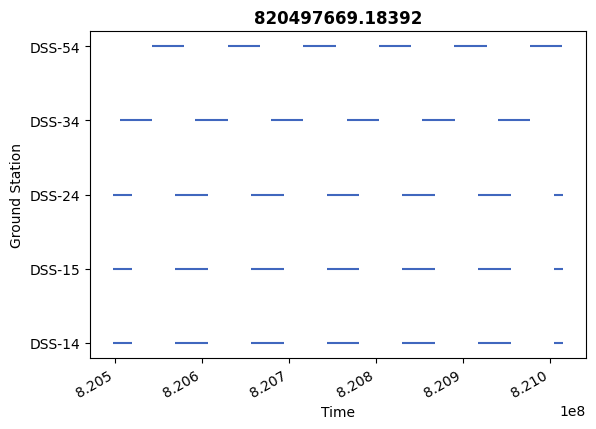

In [5]:
# Plot GSS visiblity
scb.Plotting.plot_gs_visibility(vis_windows, epochs[0].times.values)
plt.show()

## Conclusion
FILL OUT